In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
 
# =============================================================
# PROJECT 1 — House Price Prediction
# Model    : Linear Regression
# Dataset  : California Housing (20,640 samples, 8 features)
# Goal     : Predict median house price from neighborhood data
# =============================================================
 
# ─────────────────────────────────────────────
# STEP 1: Load and Explore the Data
# Each row = one census block in California.
# Target = median house price in $100,000s.
# ─────────────────────────────────────────────
 
print("=" * 65)
print("STEP 1 — Load and Explore the Data")
print("=" * 65)
 
data = fetch_california_housing()
df   = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target
 
print(df.head(10))
print(f"\nTotal samples      : {len(df):,}")
print(f"Number of features : {df.shape[1] - 1}")
print(f"Price range        : ${df['Price'].min():.2f} – ${df['Price'].max():.2f} (×$100K)")
print(f"Average price      : ${df['Price'].mean():.2f} × $100,000")
print(f"\nBasic Statistics:\n{df.describe().round(2)}")
 

STEP 1 — Load and Explore the Data
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
5  4.0368      52.0  4.761658   1.103627       413.0  2.139896     37.85   
6  3.6591      52.0  4.931907   0.951362      1094.0  2.128405     37.84   
7  3.1200      52.0  4.797527   1.061824      1157.0  1.788253     37.84   
8  2.0804      42.0  4.294118   1.117647      1206.0  2.026891     37.84   
9  3.6912      52.0  4.970588   0.990196      1551.0  2.172269     37.84   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.42

In [2]:
# ─────────────────────────────────────────────
# STEP 2: Remove Outliers
# Extreme values in AveRooms and AveBedrms distort the model.
# We keep only rows within a reasonable real-world range.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 2 — Removing Outliers")
print("=" * 65)
 
before = len(df)
df = df[df['AveRooms']  < 20]
df = df[df['AveBedrms'] < 10]
after  = len(df)
 
print(f"Rows before cleaning : {before:,}")
print(f"Rows after  cleaning : {after:,}")
print(f"Rows removed         : {before - after:,}")


STEP 2 — Removing Outliers
Rows before cleaning : 20,640
Rows after  cleaning : 20,571
Rows removed         : 69


In [3]:
# ─────────────────────────────────────────────
# STEP 3: Correlation Analysis
# Correlation measures the linear relationship between
# each feature and the target (Price).
# Range: -1 to +1
#   +1 → strong positive relationship
#   -1 → strong negative relationship
#    0 → no linear relationship
# MedInc (median income) has the strongest correlation → most useful feature.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 3 — Feature Correlation with Price")
print("=" * 65)
 
correlations = df.corr()['Price'].drop('Price').sort_values(ascending=False)
 
print(f"{'Feature':<15} {'Correlation':>12}  {'Strength':>20}")
print("-" * 55)
for feat, corr in correlations.items():
    if   abs(corr) > 0.5:  strength = "🟢 Strong"
    elif abs(corr) > 0.3:  strength = "🟡 Moderate"
    else:                   strength = "🔴 Weak"
    print(f"  {feat:<13} {corr:>12.3f}  {strength:>20}")
 
top_feature = correlations.idxmax()
print(f"\n→ '{top_feature}' has the strongest correlation "
      f"({correlations[top_feature]:.2f}) with house prices.")
print("→ Higher income neighborhoods = more expensive houses.")


STEP 3 — Feature Correlation with Price
Feature          Correlation              Strength
-------------------------------------------------------
  MedInc               0.689              🟢 Strong
  AveRooms             0.274                🔴 Weak
  HouseAge             0.105                🔴 Weak
  AveOccup            -0.024                🔴 Weak
  Population          -0.026                🔴 Weak
  Longitude           -0.046                🔴 Weak
  AveBedrms           -0.089                🔴 Weak
  Latitude            -0.144                🔴 Weak

→ 'MedInc' has the strongest correlation (0.69) with house prices.
→ Higher income neighborhoods = more expensive houses.



STEP 4 — Exploratory Data Analysis (EDA)


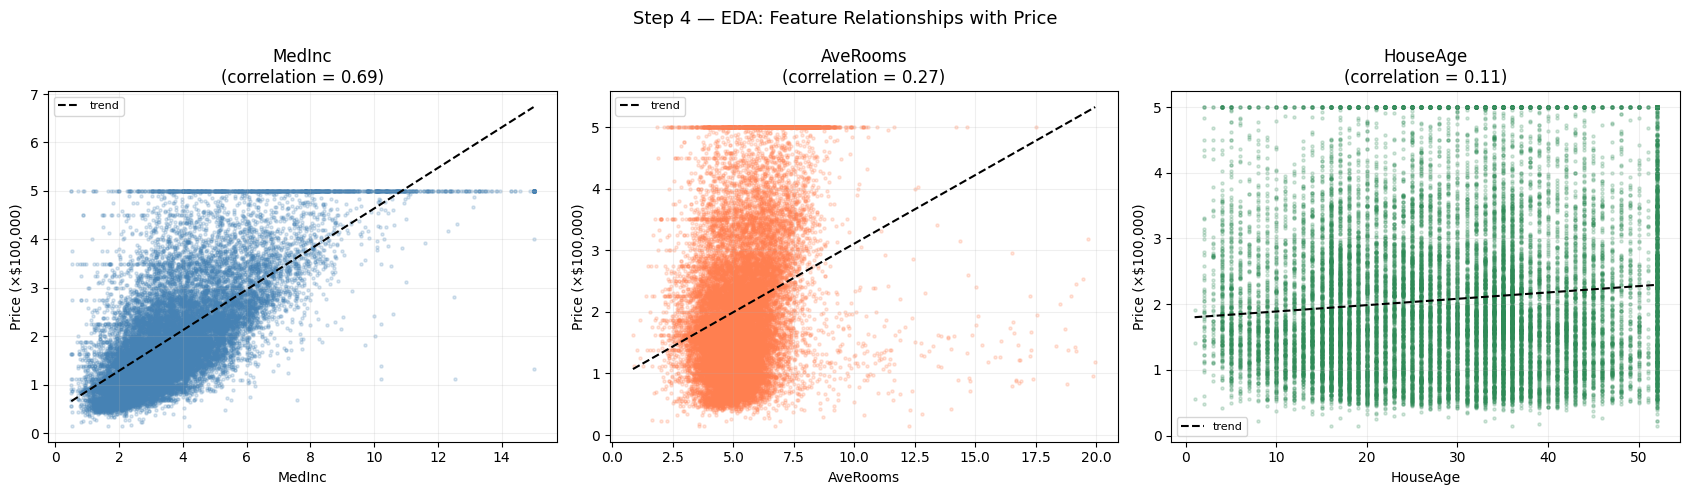

→ MedInc shows the clearest linear trend with price.


In [4]:
# ─────────────────────────────────────────────
# STEP 4: Exploratory Data Analysis (EDA)
# Visualize relationships between features and price.
# A linear trend confirms Linear Regression is appropriate.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 4 — Exploratory Data Analysis (EDA)")
print("=" * 65)
 
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Step 4 — EDA: Feature Relationships with Price", fontsize=13)
 
plot_features = ['MedInc', 'AveRooms', 'HouseAge']
colors        = ['steelblue', 'coral', 'seagreen']
 
for ax, feat, color in zip(axes, plot_features, colors):
    ax.scatter(df[feat], df['Price'], alpha=0.2, s=5, color=color)
    # Add trend line
    z = np.polyfit(df[feat], df['Price'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'k--', linewidth=1.5, label='trend')
    corr = df[feat].corr(df['Price'])
    ax.set_title(f"{feat}\n(correlation = {corr:.2f})")
    ax.set_xlabel(feat)
    ax.set_ylabel("Price (×$100,000)")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.2)
 
plt.tight_layout()
plt.savefig("eda_correlations.png", dpi=150)
plt.show()
print("→ MedInc shows the clearest linear trend with price.")

In [5]:
# ─────────────────────────────────────────────
# STEP 5: Feature Engineering
# We create new features by combining existing ones.
# Why? The original features may not capture the full picture.
# RoomsPerPerson = AveRooms / AveOccup
#   → measures spaciousness per person (more useful than raw rooms)
# BedroomRatio = AveBedrms / AveRooms
#   → high ratio = more bedrooms relative to total rooms
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 5 — Feature Engineering")
print("=" * 65)
 
df['RoomsPerPerson'] = df['AveRooms']  / df['AveOccup']
df['BedroomRatio']   = df['AveBedrms'] / df['AveRooms']
 
print("New features created:")
print(f"  RoomsPerPerson = AveRooms / AveOccup")
print(f"    → Measures spaciousness per person")
print(f"    → Mean: {df['RoomsPerPerson'].mean():.2f} rooms per person")
print(f"\n  BedroomRatio = AveBedrms / AveRooms")
print(f"    → Proportion of rooms that are bedrooms")
print(f"    → Mean: {df['BedroomRatio'].mean():.2f}")
 
corr_rpp = df['RoomsPerPerson'].corr(df['Price'])
corr_br  = df['BedroomRatio'].corr(df['Price'])
print(f"\n  RoomsPerPerson correlation with Price : {corr_rpp:.3f}")
print(f"  BedroomRatio   correlation with Price : {corr_br:.3f}")
print(f"\n→ Feature Engineering created new signals the original features missed.")


STEP 5 — Feature Engineering
New features created:
  RoomsPerPerson = AveRooms / AveOccup
    → Measures spaciousness per person
    → Mean: 1.93 rooms per person

  BedroomRatio = AveBedrms / AveRooms
    → Proportion of rooms that are bedrooms
    → Mean: 0.21

  RoomsPerPerson correlation with Price : 0.373
  BedroomRatio   correlation with Price : -0.255

→ Feature Engineering created new signals the original features missed.


In [7]:
# ─────────────────────────────────────────────
# STEP 6: Train / Test Split
# 80% for training, 20% for testing.
# random_state=42 ensures reproducible results.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 6 — Train/Test Split (80/20)")
print("=" * 65)
 
features_4    = ['AveRooms', 'AveBedrms', 'Population', 'MedInc']
features_all  = data.feature_names + ['RoomsPerPerson', 'BedroomRatio']
 
X_4   = df[features_4]
X_all = df[features_all]
y     = df['Price']
 
X_train_4, X_test_4, y_train, y_test = train_test_split(
    X_4, y, test_size=0.2, random_state=42
)
X_train_all, X_test_all, _, _ = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)
 
print(f"Training samples : {len(X_train_4):,}")
print(f"Test samples     : {len(X_test_4):,}")
print(f"4-feature set    : {features_4}")
print(f"Full feature set : {len(features_all)} features (original + engineered)")


STEP 6 — Train/Test Split (80/20)
Training samples : 16,456
Test samples     : 4,115
4-feature set    : ['AveRooms', 'AveBedrms', 'Population', 'MedInc']
Full feature set : 10 features (original + engineered)


In [8]:
# ─────────────────────────────────────────────
# STEP 7: StandardScaler
# Linear Regression with gradient-based solvers
# converges faster when features are on the same scale.
# Rule: fit on train only → transform both train and test.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 7 — Feature Scaling (StandardScaler)")
print("=" * 65)
 
scaler_4   = StandardScaler()
scaler_all = StandardScaler()
 
X_train_4_sc   = scaler_4.fit_transform(X_train_4)
X_test_4_sc    = scaler_4.transform(X_test_4)
 
X_train_all_sc = scaler_all.fit_transform(X_train_all)
X_test_all_sc  = scaler_all.transform(X_test_all)
 
print("Before scaling — MedInc:")
print(f"  mean={X_train_4['MedInc'].mean():.3f},  std={X_train_4['MedInc'].std():.3f}")
print("After  scaling — MedInc:")
print(f"  mean={X_train_4_sc[:,3].mean():.3f},  std={X_train_4_sc[:,3].std():.3f}")
print("\n→ All features now have mean=0, std=1 → equal contribution to the model.")


STEP 7 — Feature Scaling (StandardScaler)
Before scaling — MedInc:
  mean=3.875,  std=1.898
After  scaling — MedInc:
  mean=-0.000,  std=1.000

→ All features now have mean=0, std=1 → equal contribution to the model.


In [9]:
# ─────────────────────────────────────────────
# STEP 8: Train Both Models and Evaluate
# Model 1: 4 selected features
# Model 2: all features + engineered features
# We compare R² and RMSE to measure the impact of Feature Engineering.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 8 — Model Training & Evaluation")
print("=" * 65)
 
model_4   = LinearRegression()
model_all = LinearRegression()
 
model_4.fit(X_train_4_sc,   y_train)
model_all.fit(X_train_all_sc, y_train)
 
y_pred_4   = model_4.predict(X_test_4_sc)
y_pred_all = model_all.predict(X_test_all_sc)
 
r2_4   = r2_score(y_test, y_pred_4)
r2_all = r2_score(y_test, y_pred_all)
rmse_4   = np.sqrt(mean_squared_error(y_test, y_pred_4))
rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))
 
print(f"\n{'Metric':<28} {'4 Features':>12} {'All Features':>14} {'Improvement':>13}")
print("-" * 70)
print(f"  {'R² Score':<26} {r2_4:>12.3f} {r2_all:>14.3f} {r2_all-r2_4:>+13.3f}")
print(f"  {'RMSE (×$100K)':<26} {rmse_4:>12.3f} {rmse_all:>14.3f} {rmse_all-rmse_4:>+13.3f}")
print(f"  {'Training Samples':<26} {len(X_train_4):>12,} {len(X_train_all):>14,}")
print(f"  {'Test Samples':<26} {len(X_test_4):>12,} {len(X_test_all):>14,}")
 
print(f"\n→ R² went from {r2_4:.3f} → {r2_all:.3f} (+{r2_all-r2_4:.3f})")
print(f"→ The full model explains {r2_all*100:.1f}% of house price variance.")
print(f"→ Remaining {(1-r2_all)*100:.1f}% = irreducible error (location, renovations, etc.)")
print(f"→ Key Finding: Feature Engineering directly impacts model performance.")
 
# Coefficients for 4-feature model
print(f"\nCoefficients (4-feature model):")
for feat, coef in zip(features_4, model_4.coef_):
    direction = "increases" if coef > 0 else "decreases"
    print(f"  {feat:<15} → price {direction} by ${abs(coef)*100_000:,.0f} per unit increase")
 


STEP 8 — Model Training & Evaluation

Metric                         4 Features   All Features   Improvement
----------------------------------------------------------------------
  R² Score                          0.521          0.671        +0.149
  RMSE (×$100K)                     0.796          0.660        -0.136
  Training Samples                 16,456         16,456
  Test Samples                      4,115          4,115

→ R² went from 0.521 → 0.671 (+0.149)
→ The full model explains 67.1% of house price variance.
→ Remaining 32.9% = irreducible error (location, renovations, etc.)
→ Key Finding: Feature Engineering directly impacts model performance.

Coefficients (4-feature model):
  AveRooms        → price decreases by $43,912 per unit increase
  AveBedrms       → price increases by $23,953 per unit increase
  Population      → price decreases by $5,113 per unit increase
  MedInc          → price increases by $108,211 per unit increase



STEP 9 — Visualization


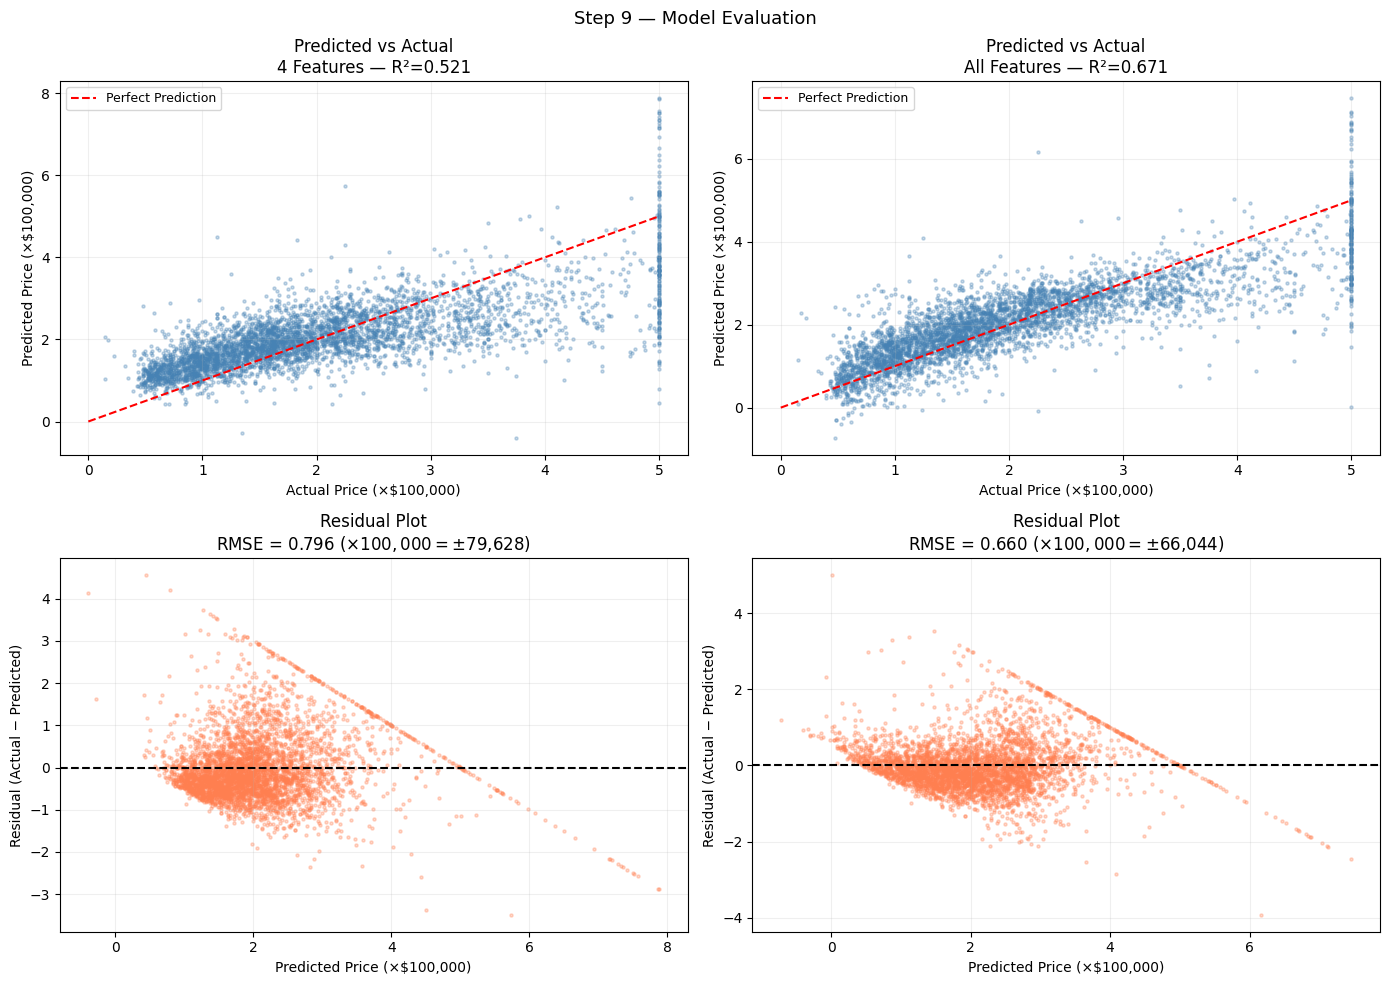

Plot saved → 'model_evaluation.png'


In [10]:
# ─────────────────────────────────────────────
# STEP 9: Visualization — Predicted vs Actual + Residuals
# Perfect model: all points on the red diagonal.
# Residuals should be randomly distributed around 0.
# Patterns in residuals = the model is missing something.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 9 — Visualization")
print("=" * 65)
 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Step 9 — Model Evaluation", fontsize=13)
 
for col, (y_pred, r2, rmse, title) in enumerate([
    (y_pred_4,   r2_4,   rmse_4,   f"4 Features — R²={r2_4:.3f}"),
    (y_pred_all, r2_all, rmse_all, f"All Features — R²={r2_all:.3f}"),
]):
    # Predicted vs Actual
    axes[0][col].scatter(y_test, y_pred, alpha=0.3, s=5, color='steelblue')
    axes[0][col].plot([0, 5], [0, 5], 'r--', linewidth=1.5, label='Perfect Prediction')
    axes[0][col].set_xlabel("Actual Price (×$100,000)")
    axes[0][col].set_ylabel("Predicted Price (×$100,000)")
    axes[0][col].set_title(f"Predicted vs Actual\n{title}")
    axes[0][col].legend(fontsize=9)
    axes[0][col].grid(True, alpha=0.2)
 
    # Residuals plot
    residuals = y_test - y_pred
    axes[1][col].scatter(y_pred, residuals, alpha=0.3, s=5, color='coral')
    axes[1][col].axhline(y=0, color='black', linestyle='--', linewidth=1.5)
    axes[1][col].set_xlabel("Predicted Price (×$100,000)")
    axes[1][col].set_ylabel("Residual (Actual − Predicted)")
    axes[1][col].set_title(f"Residual Plot\nRMSE = {rmse:.3f} (×$100,000 = ±${rmse*100_000:,.0f})")
    axes[1][col].grid(True, alpha=0.2)
 
plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150)
plt.show()
print("Plot saved → 'model_evaluation.png'")

In [11]:
# ─────────────────────────────────────────────
# STEP 10: Interactive Price Predictor
# Predict the price for any new house given its measurements.
# This matches the README usage example exactly.
# ─────────────────────────────────────────────
 
print("\n" + "=" * 65)
print("STEP 10 — Interactive Price Predictor")
print("=" * 65)
 
def predict_price(MedInc, AveRooms, AveBedrms, Population,
                  HouseAge=20, AveOccup=3.0, Latitude=34.0, Longitude=-118.0):
    """
    Predicts the median house price for a given neighborhood.
    Uses the full-feature model with StandardScaler pipeline.
 
    Args:
        MedInc      : Median income in the block (tens of thousands USD)
        AveRooms    : Average number of rooms per household
        AveBedrms   : Average number of bedrooms per household
        Population  : Block population
        HouseAge    : Median house age in years
        AveOccup    : Average household occupancy
        Latitude    : Block latitude
        Longitude   : Block longitude
 
    Returns:
        float: Predicted price in dollars.
    """
    rooms_per_person = AveRooms  / AveOccup
    bedroom_ratio    = AveBedrms / AveRooms
 
    features = np.array([[MedInc, HouseAge, AveRooms, AveBedrms,
                           Population, AveOccup, Latitude, Longitude,
                           rooms_per_person, bedroom_ratio]])
 
    scaled    = scaler_all.transform(features)
    predicted = model_all.predict(scaled)[0]
    price_usd = predicted * 100_000
 
    print(f"  Input  : MedInc={MedInc}, AveRooms={AveRooms}, "
          f"HouseAge={HouseAge}, Population={Population}")
    print(f"  Output : Predicted Price → ${price_usd:,.0f}")
    print()
    return price_usd
 
print("Testing the predictor on sample inputs:\n")
predict_price(MedInc=8.3,  AveRooms=6.9,  AveBedrms=1.0, Population=322,  HouseAge=41)
predict_price(MedInc=3.5,  AveRooms=4.5,  AveBedrms=1.1, Population=1200, HouseAge=25)
predict_price(MedInc=1.5,  AveRooms=3.0,  AveBedrms=1.2, Population=800,  HouseAge=50)
predict_price(MedInc=12.0, AveRooms=8.0,  AveBedrms=1.5, Population=200,  HouseAge=15)
 


STEP 10 — Interactive Price Predictor
Testing the predictor on sample inputs:

  Input  : MedInc=8.3, AveRooms=6.9, HouseAge=41, Population=322
  Output : Predicted Price → $379,706

  Input  : MedInc=3.5, AveRooms=4.5, HouseAge=25, Population=1200
  Output : Predicted Price → $183,213

  Input  : MedInc=1.5, AveRooms=3.0, HouseAge=50, Population=800
  Output : Predicted Price → $168,528

  Input  : MedInc=12.0, AveRooms=8.0, HouseAge=15, Population=200
  Output : Predicted Price → $510,041



/Users/rasha/Desktop/AI-projects/house-price-prediction/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/rasha/Desktop/AI-projects/house-price-prediction/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/rasha/Desktop/AI-projects/house-price-prediction/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/Users/rasha/Desktop/AI-projects/house-price-prediction/venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


np.float64(510040.83031139115)

In [12]:
# ─────────────────────────────────────────────
# STEP 11: Key Learnings
# ─────────────────────────────────────────────
 
print("=" * 65)
print("STEP 11 — Key Learnings")
print("=" * 65)
print(f"""
  1. Feature Correlation
     → MedInc had the strongest correlation ({correlations['MedInc']:.2f}) with price.
     → Higher income neighborhoods consistently have more expensive houses.
     → Always check correlation BEFORE selecting features.
 
  2. Feature Engineering
     → RoomsPerPerson and BedroomRatio created new signals.
     → R² improved from {r2_4:.3f} → {r2_all:.3f} (+{r2_all-r2_4:.3f}) by adding these features.
     → Feature Engineering often gives bigger gains than model tuning.
 
  3. StandardScaler
     → Normalized features to mean=0, std=1.
     → Prevents features with large ranges from dominating the model.
     → Rule: always fit on train only, then transform both sets.
 
  4. R² Score Interpretation
     → Model explains {r2_all*100:.1f}% of house price variance.
     → Remaining {(1-r2_all)*100:.1f}% = irreducible error.
     → Factors not in the data: exact location, renovations, school quality.
 
  5. RMSE Interpretation
     → RMSE = {rmse_all:.3f} × $100,000 = ±${rmse_all*100_000:,.0f} average error.
     → This is the typical gap between predicted and actual price.
     → Lower is better; further improvements need non-linear models.
 
  6. Linear Regression Limitation
     → Assumes a straight-line relationship between features and price.
     → Real estate pricing is non-linear → Random Forest or XGBoost next.
""")
 
print("=" * 65)
print("✅ All steps complete.")
print("   Saved: 'eda_correlations.png'")
print("   Saved: 'model_evaluation.png'")
print("=" * 65)

STEP 11 — Key Learnings

  1. Feature Correlation
     → MedInc had the strongest correlation (0.69) with price.
     → Higher income neighborhoods consistently have more expensive houses.
     → Always check correlation BEFORE selecting features.

  2. Feature Engineering
     → RoomsPerPerson and BedroomRatio created new signals.
     → R² improved from 0.521 → 0.671 (+0.149) by adding these features.
     → Feature Engineering often gives bigger gains than model tuning.

  3. StandardScaler
     → Normalized features to mean=0, std=1.
     → Prevents features with large ranges from dominating the model.
     → Rule: always fit on train only, then transform both sets.

  4. R² Score Interpretation
     → Model explains 67.1% of house price variance.
     → Remaining 32.9% = irreducible error.
     → Factors not in the data: exact location, renovations, school quality.

  5. RMSE Interpretation
     → RMSE = 0.660 × $100,000 = ±$66,044 average error.
     → This is the typical gap bet